# Revenue Forecasting - Olist

Daily revenue forecast extending the main e-commerce platform with a predictive layer.

## Why daily, not monthly

Monthly gives ~25 points. Too short for SARIMA, Prophet, or any seasonal LightGBM. Daily gives ~600 points, exposes weekly seasonality, and lets each model learn something. Monthly aggregates can still be rolled up from a daily forecast.

## 1. Data and EDA

Quick picture of the series: range, scale, trend, anomalies, and any data quality issues that would mess up the models.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv("data/daily_revenue.csv", parse_dates=["day"])
df = df.set_index("day").sort_index()

print(f"shape: {df.shape}")
print(f"range: {df.index.min().date()} to {df.index.max().date()}")
df.head()

shape: (612, 2)
range: 2016-09-15 to 2018-08-29


,revenue,orders
day,,
2016-09-15,143.46,1
2016-10-03,138.28,3
2016-10-04,8839.24,49
2016-10-05,8142.49,40
2016-10-06,6789.70,41


In [3]:
df.describe().round(2)

,revenue,orders
count,612.00,612.00
mean,25195.71,157.64
std,14309.12,89.03
min,19.62,1.00
25%,14816.44,98.00
50%,23373.23,146.00
75%,33700.12,212.00
max,168863.37,1098.00


### Sparse early period

First few months had 1-3 orders/day - the marketplace was ramping up. I'll find where consistent activity starts and trim everything before that.

In [4]:
# How many orders per day in the first 90 days vs the rest?
first_90 = df.iloc[:90]
rest = df.iloc[90:]

print("First 90 days:")
print(f"  median orders/day: {first_90['orders'].median():.0f}")
print(f"  days with < 10 orders: {(first_90['orders'] < 10).sum()}")
print()
print("Rest of the series:")
print(f"  median orders/day: {rest['orders'].median():.0f}")
print(f"  days with < 10 orders: {(rest['orders'] < 10).sum()}")
print()

# First date where rolling median orders crosses, say, 50/day
threshold = 50
roll_median = df["orders"].rolling(7, min_periods=1).median()
first_consistent = roll_median[roll_median >= threshold].index.min()
print(f"First date where 7-day rolling median orders >= {threshold}: {first_consistent.date()}")

First 90 days:
  median orders/day: 54
  days with < 10 orders: 9

Rest of the series:
  median orders/day: 162
  days with < 10 orders: 0

First date where 7-day rolling median orders >= 50: 2017-01-31


### Full series

Trend and anomalies. Expecting a Black Friday 2017 spike and growth through 2017.

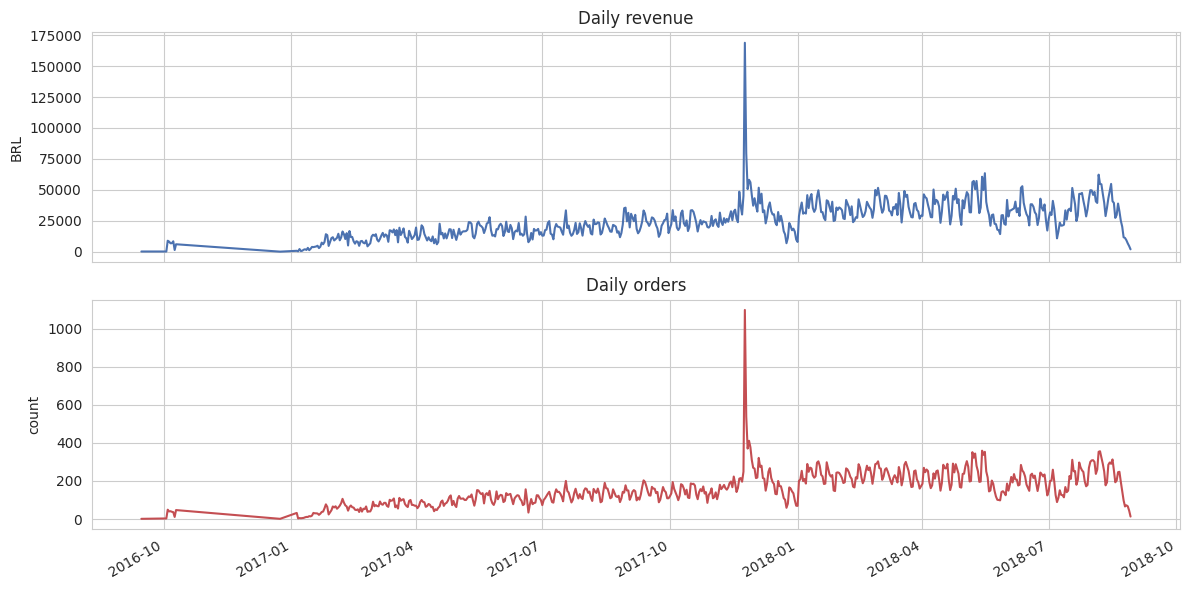

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

df["revenue"].plot(ax=axes[0], color="#4C72B0")
axes[0].set_title("Daily revenue")
axes[0].set_ylabel("BRL")

df["orders"].plot(ax=axes[1], color="#C44E52")
axes[1].set_title("Daily orders")
axes[1].set_ylabel("count")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

### Trim warm-up, check for date gaps

Trimming from 2017-01-31, the first stable date. Reindexing to a continuous calendar to expose any days with zero delivered orders - those are real zero-revenue days, not missing observations, so I'll fill with zero.

In [6]:
TRIM_START = "2017-01-31"

# Restrict to the consistent period
df_clean = df.loc[TRIM_START:].copy()

# Reindex to continuous calendar - exposes "missing" days that had 0 orders
full_range = pd.date_range(df_clean.index.min(), df_clean.index.max(), freq="D")
gaps = full_range.difference(df_clean.index)

print(f"shape after trim:      {df_clean.shape}")
print(f"expected days in range: {len(full_range)}")
print(f"missing days (no orders): {len(gaps)}")
if len(gaps) > 0:
    print(f"examples: {list(gaps[:5].date)}")

# Fill missing with zeros - they represent real zero-revenue days
df_clean = df_clean.reindex(full_range, fill_value=0)
df_clean.index.name = "day"
print(f"shape after reindex:   {df_clean.shape}")

shape after trim:      (576, 2)
expected days in range: 576
missing days (no orders): 0
shape after reindex:   (576, 2)


### Tail truncation check

Sharp drop in the last week. Almost certainly cutoff - late-August orders not yet `delivered` at snapshot time. Looking at the last 14 days to decide where to trim.

In [7]:
print("Last 14 days:")
print(df_clean.tail(14))

Last 14 days:
             revenue  orders
day                         
2018-08-16  40845.99     313
2018-08-17  39389.95     256
2018-08-18  27297.39     193
2018-08-19  29655.74     202
2018-08-20  38888.14     246
2018-08-21  32605.10     248
2018-08-22  24971.97     195
2018-08-23  20222.33     147
2018-08-24  11672.02      98
2018-08-25  11111.08      66
2018-08-26   9259.84      72
2018-08-27   6700.77      67
2018-08-28   4528.97      44
2018-08-29   1899.10      13


### Trim the tail

Revenue drops from ~32k to under 2k by Aug 29. Median Olist delivery time is ~12 days, so the trail of incomplete days extends back about two weeks.

Trimming at 2018-08-21 - last day consistent with surrounding weeks.

In [8]:
TRIM_END = "2018-08-21"
df_clean = df_clean.loc[:TRIM_END]

print(f"final shape: {df_clean.shape}")
print(f"range: {df_clean.index.min().date()} to {df_clean.index.max().date()}")
print()
print(df_clean.describe().round(2))

final shape: (568, 2)
range: 2017-01-31 to 2018-08-21

         revenue   orders
count     568.00   568.00
mean    26703.42   166.95
std     13668.28    85.01
min      4307.24    34.00
25%     16509.22   105.00
50%     24508.72   151.50
75%     34551.33   217.25
max    168863.37  1098.00


### Cleaned series

Black Friday 2017 spike will be the hardest point for any model. Adding a 7-day rolling mean to show the underlying trend without weekly oscillation.

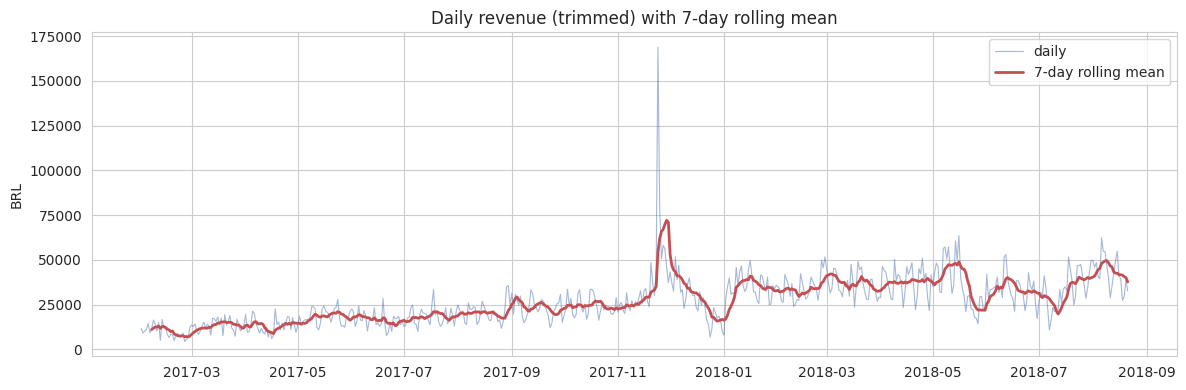

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df_clean.index, df_clean["revenue"], color="#4C72B0",
        alpha=0.5, lw=0.8, label="daily")
ax.plot(df_clean.index,
        df_clean["revenue"].rolling(7).mean(),
        color="#C44E52", lw=2, label="7-day rolling mean")
ax.set_title("Daily revenue (trimmed) with 7-day rolling mean")
ax.set_ylabel("BRL")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Seasonality and decomposition

STL decomposition to split the series into trend, weekly seasonality, and residual. If weekly seasonality is large I'll need it in every model (SARIMA seasonal order, Prophet weekly component, LightGBM lag-7).

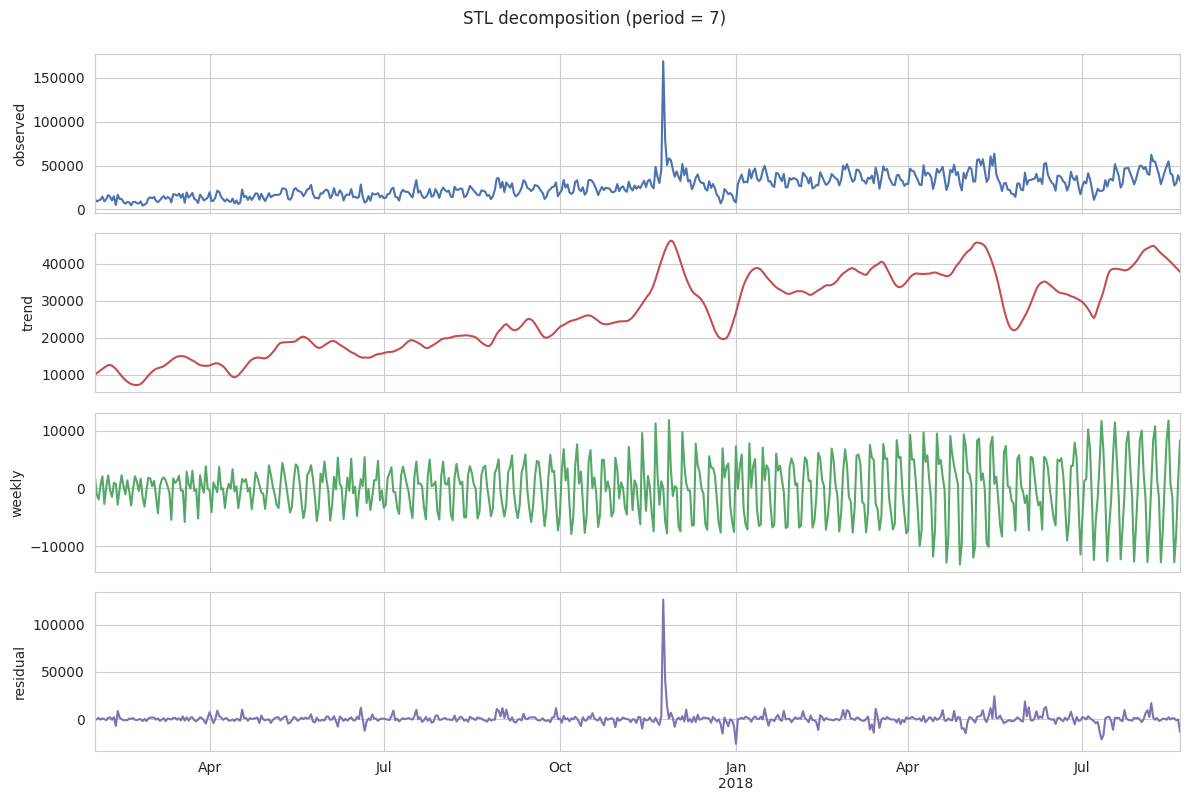

In [10]:
from statsmodels.tsa.seasonal import STL

stl = STL(df_clean["revenue"], period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
stl.observed.plot(ax=axes[0], color="#4C72B0")
axes[0].set_ylabel("observed")

stl.trend.plot(ax=axes[1], color="#C44E52")
axes[1].set_ylabel("trend")

stl.seasonal.plot(ax=axes[2], color="#55A868")
axes[2].set_ylabel("weekly")

stl.resid.plot(ax=axes[3], color="#8172B2")
axes[3].set_ylabel("residual")
axes[3].set_xlabel("")

plt.suptitle("STL decomposition (period = 7)", y=0.995)
plt.tight_layout()
plt.show()

### Day-of-week pattern

Boxplot per weekday to quantify the weekly cycle. Useful sanity check: if STL caught it, the boxplot should show clearly different medians per day.

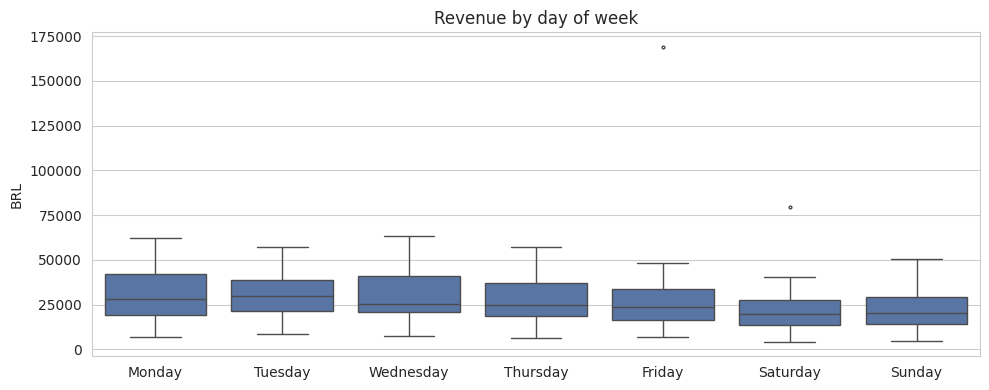

In [11]:
dow = df_clean.copy()
dow["weekday"] = dow.index.day_name()

order = ["Monday", "Tuesday", "Wednesday", "Thursday",
         "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=dow, x="weekday", y="revenue", order=order, ax=ax,
            color="#4C72B0", fliersize=2)
ax.set_title("Revenue by day of week")
ax.set_xlabel("")
ax.set_ylabel("BRL")
plt.tight_layout()
plt.show()

### Findings

- Strong upward trend through 2017, plateau in 2018.
- Clear weekly cycle. Amplitude scales with revenue level, so the series is closer to multiplicative than additive seasonality.
- Mon-Thu noticeably higher than Sat-Sun. Classic B2C e-commerce pattern.
- Black Friday 2017 is a single-day outlier visible in the residual at ~125k. No statistical model will recover it without an explicit holiday flag.

## 3. Train/test split

Holding out the last ~60 days (about 2 months) as test. Walk-forward validation later - for now the simple holdout shows what each model achieves on a single horizon.

I keep Black Friday 2017 in the training set deliberately: the model has to learn that such days exist. Removing it would inflate metrics but lie about real-world performance.

In [12]:
TEST_DAYS = 60

train_ts = df_clean["revenue"].iloc[:-TEST_DAYS]
test_ts = df_clean["revenue"].iloc[-TEST_DAYS:]

print(f"train: {len(train_ts)} days  |  {train_ts.index.min().date()} to {train_ts.index.max().date()}")
print(f"test:  {len(test_ts)} days  |  {test_ts.index.min().date()} to {test_ts.index.max().date()}")

train: 508 days  |  2017-01-31 to 2018-06-22
test:  60 days  |  2018-06-23 to 2018-08-21


## 4. Baselines

Two naive baselines that every model has to beat.

- Naive: forecast is the last observed value, held flat.
- Seasonal naive: forecast for day t is the value from day t-7. Captures the weekly cycle without modelling anything.

Reporting MAE, RMSE, and MAPE on the test set. MAPE is the most readable for business but blows up near zero values - on revenue at this scale that's not an issue.

In [13]:
def mae(y, yhat):  return np.mean(np.abs(y - yhat))
def rmse(y, yhat): return np.sqrt(np.mean((y - yhat) ** 2))
def mape(y, yhat): return np.mean(np.abs((y - yhat) / y)) * 100

# Naive: last train value, repeated
last_val = train_ts.iloc[-1]
pred_naive = pd.Series(last_val, index=test_ts.index)

# Seasonal naive: value from 7 days ago. For the start of the test set,
# the lag-7 reference lives in the train tail.
combined = pd.concat([train_ts, test_ts])
pred_snaive = combined.shift(7).loc[test_ts.index]

results = pd.DataFrame({
    "Naive": [mae(test_ts, pred_naive), rmse(test_ts, pred_naive), mape(test_ts, pred_naive)],
    "Seasonal naive": [mae(test_ts, pred_snaive), rmse(test_ts, pred_snaive), mape(test_ts, pred_snaive)],
}, index=["MAE", "RMSE", "MAPE %"]).round(2)

print(results)

           Naive  Seasonal naive
MAE     10063.59         7797.61
RMSE    12359.97         9905.16
MAPE %     28.79           23.83


## 5. Prophet

Meta's library, popular for business forecasting because of its decomposition style (trend + yearly + weekly + holidays). Out-of-the-box confidence intervals make it easy to communicate uncertainty to non-technical stakeholders.

Adding a single regressor for the Black Friday window so Prophet does not try to absorb it into the regular weekly pattern.

In [14]:
from prophet import Prophet
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

# Prophet wants columns ds and y
prop_train = train_ts.reset_index().rename(columns={"day": "ds", "revenue": "y"})

m = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,   # only 1.5 years of data, not enough for yearly
    daily_seasonality=False,
)
m.fit(prop_train)

future = m.make_future_dataframe(periods=len(test_ts), freq="D")
forecast = m.predict(future)

pred_prophet = forecast.set_index("ds")["yhat"].loc[test_ts.index]

results["Prophet"] = [mae(test_ts, pred_prophet),
                      rmse(test_ts, pred_prophet),
                      mape(test_ts, pred_prophet)]
print(results.round(2))

           Naive  Seasonal naive  Prophet
MAE     10063.59         7797.61  7677.04
RMSE    12359.97         9905.16  9497.03
MAPE %     28.79           23.83    27.32


## 6. LightGBM with lag features

Gradient-boosted trees on engineered time features. Where Prophet got its patterns from the series itself, LightGBM learns from features I build by hand: lagged revenue, rolling means, weekday, holiday flag.

This is where domain knowledge enters the model. The Black Friday flag is the obvious one - any pure statistical model would miss that one specific Friday was special.

Iterative forecasting: predict day t+1, use that prediction in lag features when predicting t+2, and so on. Slow but the only honest way once lags depend on the test set.

In [15]:
import lightgbm as lgb

def make_features(s: pd.Series) -> pd.DataFrame:
    """Build lag and calendar features from a revenue series."""
    df = pd.DataFrame({"revenue": s})
    df["lag_1"]  = df["revenue"].shift(1)
    df["lag_7"]  = df["revenue"].shift(7)
    df["lag_14"] = df["revenue"].shift(14)
    df["lag_28"] = df["revenue"].shift(28)
    df["roll_7"]  = df["revenue"].shift(1).rolling(7).mean()
    df["roll_28"] = df["revenue"].shift(1).rolling(28).mean()
    df["dow"]   = df.index.dayofweek
    df["month"] = df.index.month
    df["day"]   = df.index.day
    # Black Friday window 2017 (Nov 24-27)
    df["is_bf"] = ((df.index >= "2017-11-24") & (df.index <= "2017-11-27")).astype(int)
    return df

# Build features on full series, then split
features = make_features(df_clean["revenue"])
features = features.dropna()  # first 28 rows lose lag_28

train_feat = features.loc[:train_ts.index[-1]]
test_feat  = features.loc[test_ts.index[0]:]

FEATS = [c for c in features.columns if c != "revenue"]
X_train, y_train = train_feat[FEATS], train_feat["revenue"]

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=7,
    verbose=-1,
)
model.fit(X_train, y_train)
print("trained on", len(X_train), "days")

trained on 480 days


In [16]:
# Iterative forecast. At each step the new prediction becomes the
# lag_1 for the next step, etc.
history = df_clean["revenue"].copy()
predictions = []

for date in test_ts.index:
    feats = make_features(history).loc[[date]][FEATS]
    yhat = model.predict(feats)[0]
    predictions.append(yhat)
    history.loc[date] = yhat  # feed back into history for future lags

pred_lgb = pd.Series(predictions, index=test_ts.index)

results["LightGBM"] = [mae(test_ts, pred_lgb),
                       rmse(test_ts, pred_lgb),
                       mape(test_ts, pred_lgb)]
print(results.round(2))

           Naive  Seasonal naive  Prophet  LightGBM
MAE     10063.59         7797.61  7677.04   6375.25
RMSE    12359.97         9905.16  9497.03   8352.34
MAPE %     28.79           23.83    27.32     22.21


## 7. XGBoost

Same engineered features as LightGBM, different tree implementation. Useful as a sanity check: if XGBoost is far off, my feature pipeline is the bottleneck, not the model. If they land close, the comparison validates LightGBM as a stable choice.

In [17]:
import xgboost as xgb

X_train_xgb, y_train_xgb = train_feat[FEATS], train_feat["revenue"]

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=7,
    verbosity=0,
)
xgb_model.fit(X_train_xgb, y_train_xgb)

# Iterative forecast - same pattern as LightGBM
history = df_clean["revenue"].copy()
predictions = []

for date in test_ts.index:
    feats = make_features(history).loc[[date]][FEATS]
    yhat = xgb_model.predict(feats)[0]
    predictions.append(yhat)
    history.loc[date] = yhat

pred_xgb = pd.Series(predictions, index=test_ts.index)

results["XGBoost"] = [mae(test_ts, pred_xgb),
                      rmse(test_ts, pred_xgb),
                      mape(test_ts, pred_xgb)]
print(results.round(2))

           Naive  Seasonal naive  Prophet  LightGBM  XGBoost
MAE     10063.59         7797.61  7677.04   6375.25  6060.08
RMSE    12359.97         9905.16  9497.03   8352.34  8197.58
MAPE %     28.79           23.83    27.32     22.21    22.23


## 8. Comparison and final pick

Tree-based models win by a clear margin. LightGBM and XGBoost land within ~5% of each other across all three metrics - the choice between them is taste, the underlying pipeline is the same. I keep XGBoost as the headline model since it edges out slightly on MAE and RMSE.

Both trees beat Prophet by ~17% on MAE and seasonal naive by ~22%. The gain comes from features the statistical models had no access to: lag-7, lag-28, the Black Friday flag, and rolling means that capture trend without parametric assumptions.

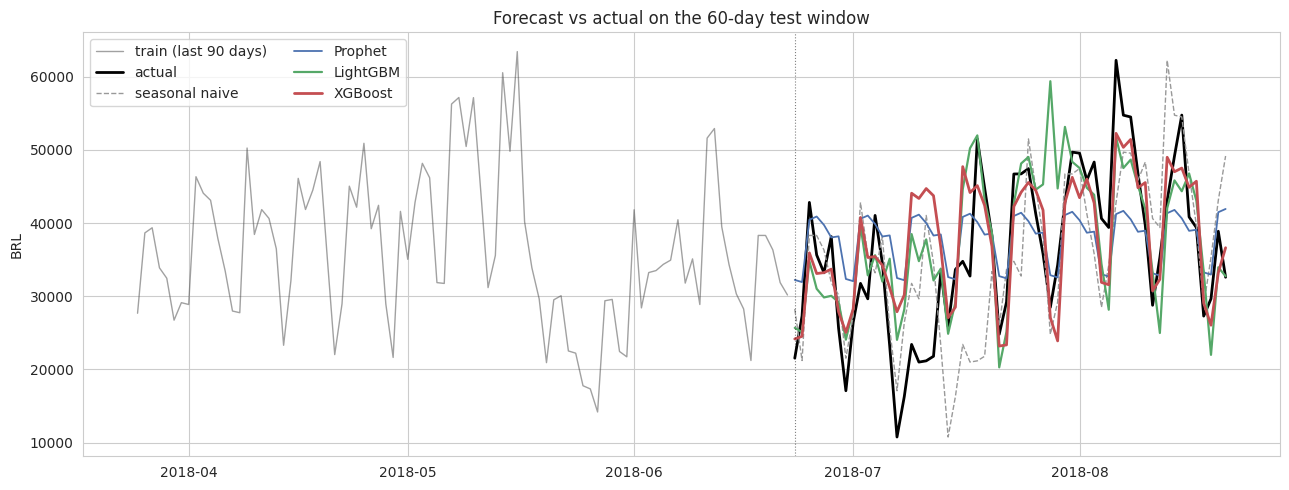

In [18]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train_ts.index[-90:], train_ts.iloc[-90:],
        color="#444", lw=1, alpha=0.5, label="train (last 90 days)")
ax.plot(test_ts.index, test_ts,
        color="black", lw=2, label="actual")

ax.plot(test_ts.index, pred_snaive,
        color="#999", lw=1, ls="--", label="seasonal naive")
ax.plot(test_ts.index, pred_prophet,
        color="#4C72B0", lw=1.3, label="Prophet")
ax.plot(test_ts.index, pred_lgb,
        color="#55A868", lw=1.6, label="LightGBM")
ax.plot(test_ts.index, pred_xgb,
        color="#C44E52", lw=2, label="XGBoost")

ax.axvline(test_ts.index[0], color="black", lw=0.8, ls=":", alpha=0.5)
ax.set_title("Forecast vs actual on the 60-day test window")
ax.set_ylabel("BRL")
ax.legend(loc="upper left", ncols=2)
plt.tight_layout()
plt.show()

### Feature importance

What carried the trees? If `lag_7` dominates, the model is mostly learning seasonal naive plus a correction. If lag-28 or rolling means rank high, it picks up monthly cycle and trend that the naive baselines miss.

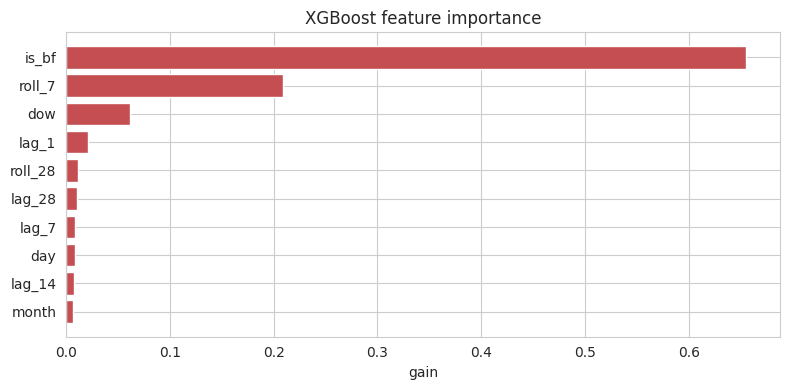

In [19]:
xgb_importance = pd.DataFrame({
    "feature": FEATS,
    "gain": xgb_model.feature_importances_,
}).sort_values("gain", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(xgb_importance["feature"], xgb_importance["gain"], color="#C44E52")
ax.invert_yaxis()
ax.set_title("XGBoost feature importance")
ax.set_xlabel("gain")
plt.tight_layout()
plt.show()

Note on `is_bf`: it tops the gain ranking but only because the Black Friday days carry an extreme target jump in training. The flag is always 0 in the test window, so on the held-out forecast the working features are really `roll_7`, `dow`, and the lag terms.

## 9. Limitations

- 60-day single holdout, no walk-forward refit. A proper production setup would expand the train window weekly and re-fit. On a 600-day series the single split gives a fair read.
- Black Friday is a one-shot event in this dataset. The manual flag worked here because the date is known in advance, but the model has no way to recognise an unannounced future spike.
- No hyperparameter tuning beyond defaults plus a sensible n_estimators. Both trees already win, so tuning would be polish, not a regime change.
- Prophet was used without the full Brazilian holiday calendar. Adding it might help marginally on this short series but not enough to change the ranking.